In [22]:
! pip install opendatasets

In [23]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
od.download("https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python")

Skipping, found downloaded files in "./customer-segmentation-tutorial-in-python" (use force=True to force download)


In [25]:
data = pd.read_csv("/content/customer-segmentation-tutorial-in-python/Mall_Customers.csv")

In [26]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [28]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [29]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [30]:
data.drop_duplicates(inplace=True)

In [31]:
data['Gender'] = data['Gender'].map({"Male": 1, "Female": 0})

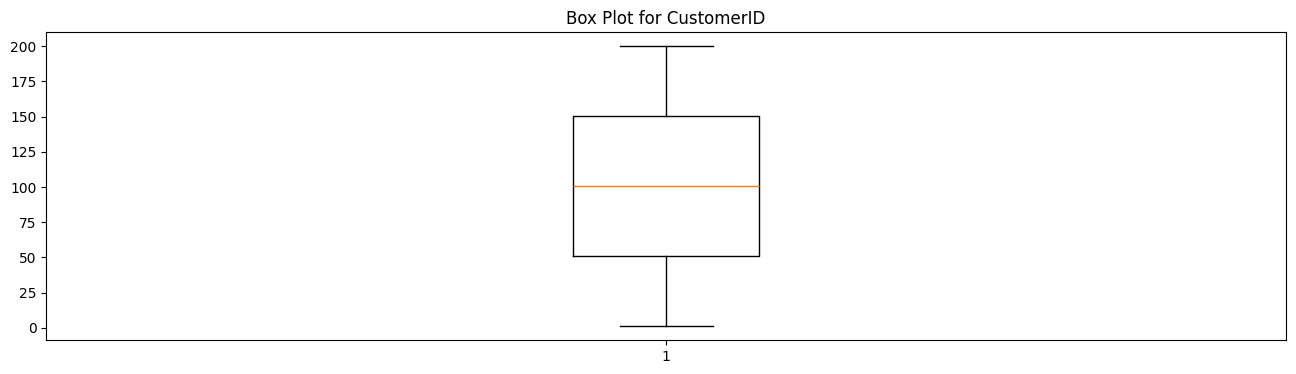

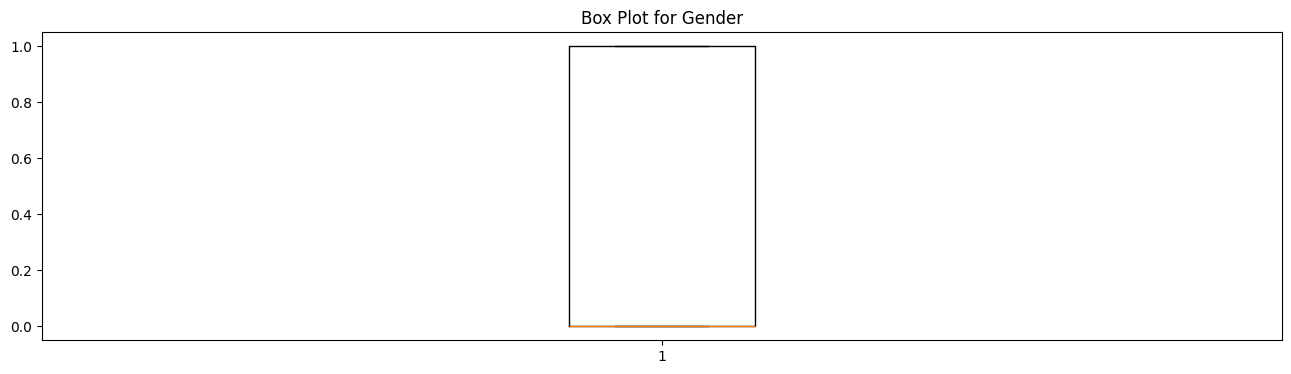

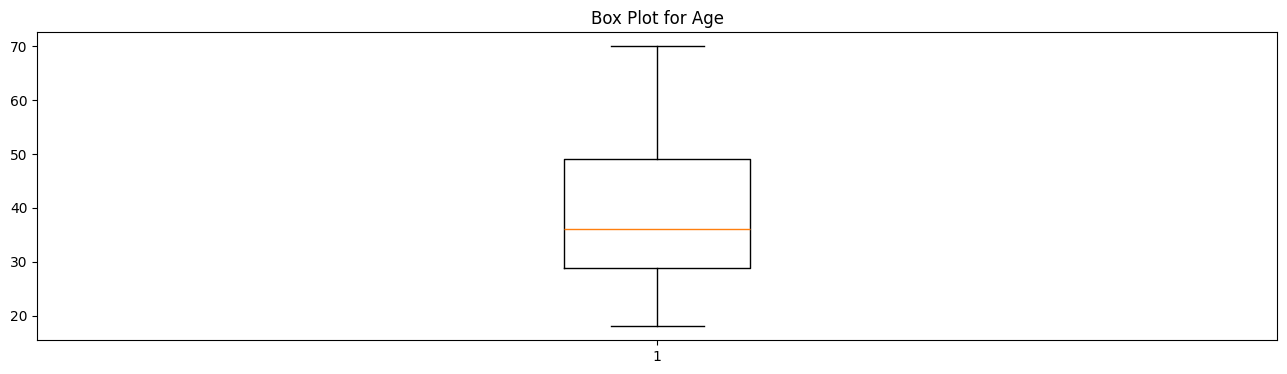

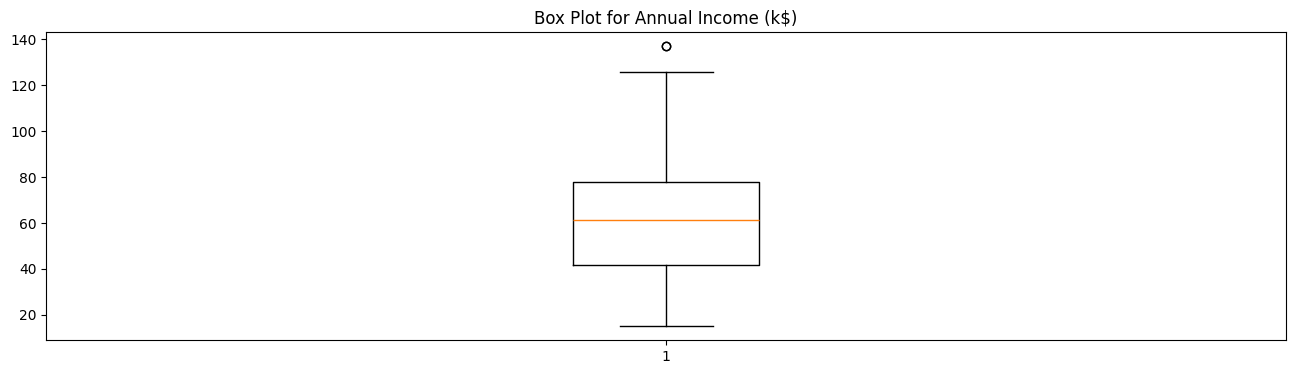

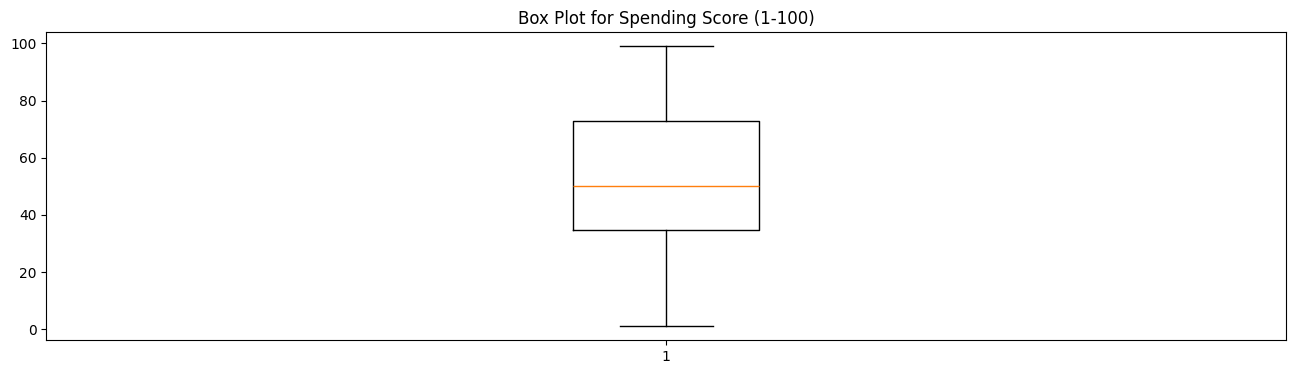

In [32]:
for col in data :
 plt.figure(figsize=(16,4))
 plt.boxplot(data[col])
 plt.title(f"Box Plot for {col}")
 plt.show()

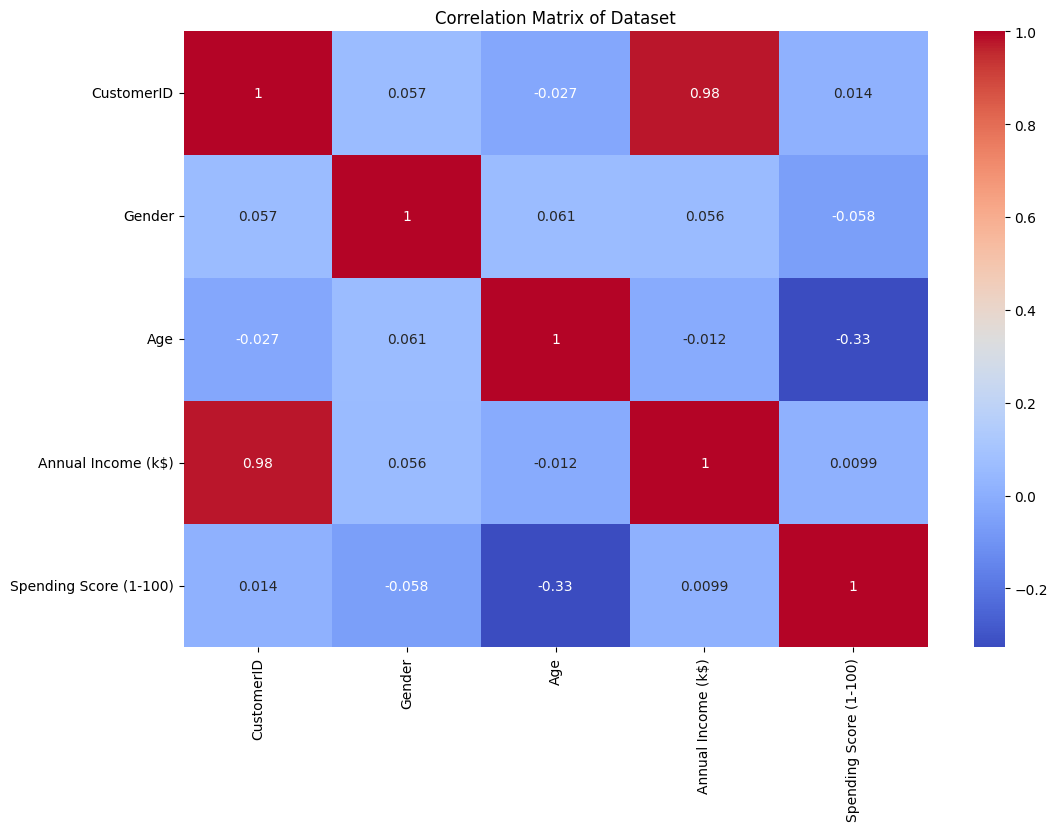

In [33]:
plt.figure(figsize=(12, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Dataset')
plt.show()

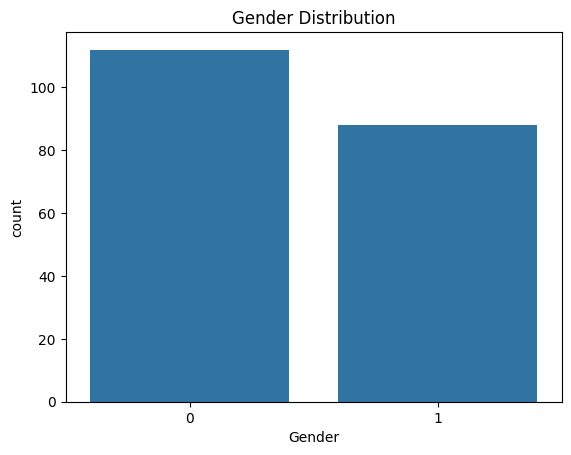

In [34]:
# mean radius distribution plot
sns.countplot(x='Gender', data=data)
plt.title('Gender Distribution')
plt.show()


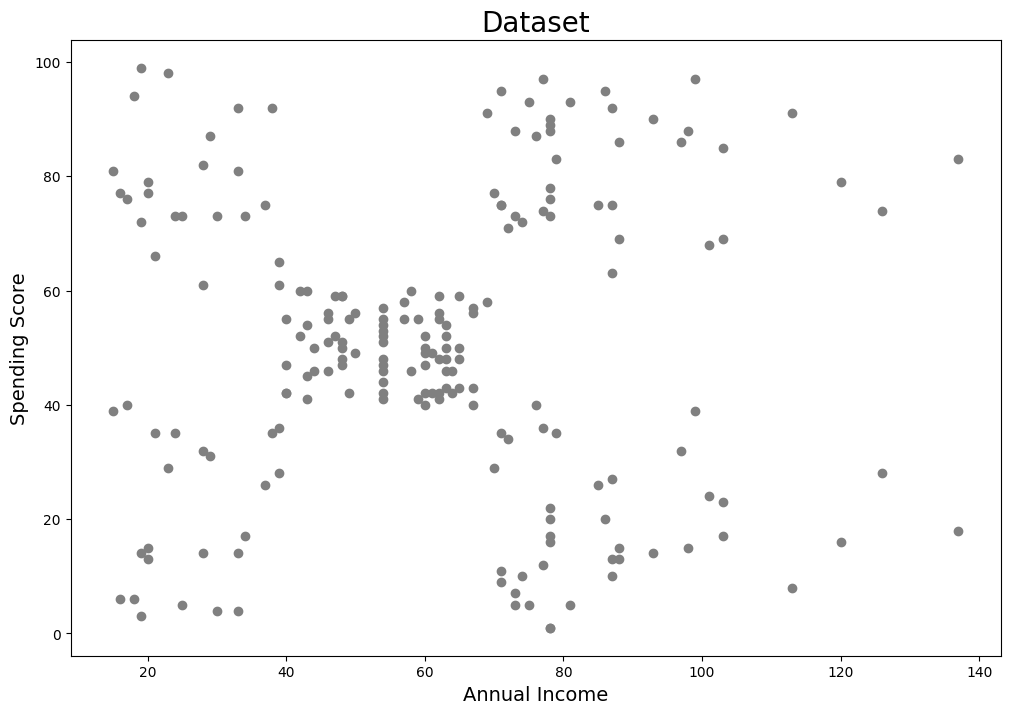

In [35]:
plt.figure(figsize=(12,8))
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], color='grey')
plt.title('Dataset', fontsize=20)
plt.xlabel('Annual Income', fontsize=14)
plt.ylabel('Spending Score', fontsize=14)
plt.show()

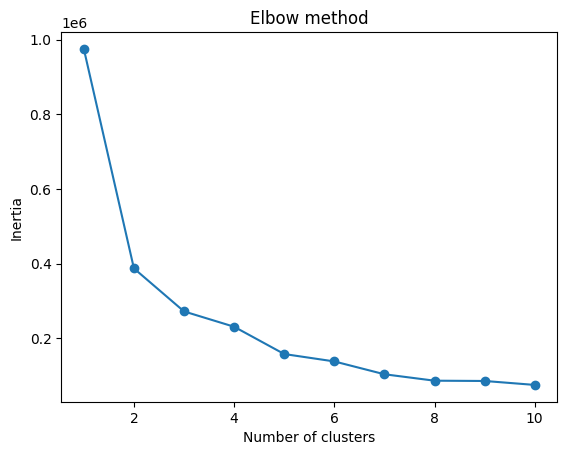

In [36]:
from sklearn.cluster import KMeans
inertias = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(data)
  inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

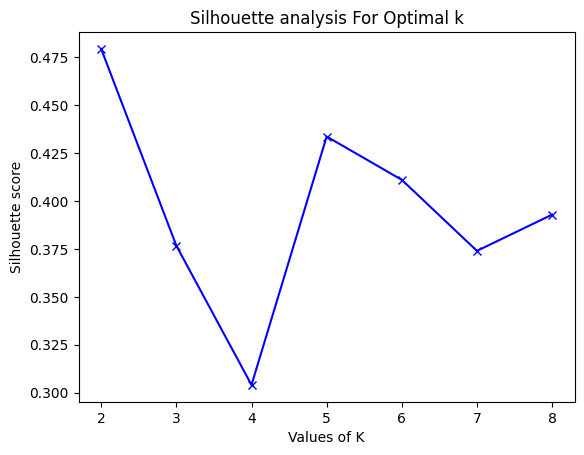

In [37]:
from sklearn.metrics import silhouette_score
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []
for num_clusters in range_n_clusters:

  # initialise kmeans
  kmeans = KMeans(n_clusters=num_clusters)
  kmeans.fit(data)
  cluster_labels = kmeans.labels_


 # silhouette score
  silhouette_avg.append(silhouette_score(data, cluster_labels))
plt.plot(range_n_clusters,silhouette_avg,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)


KMeans(n_clusters=2)

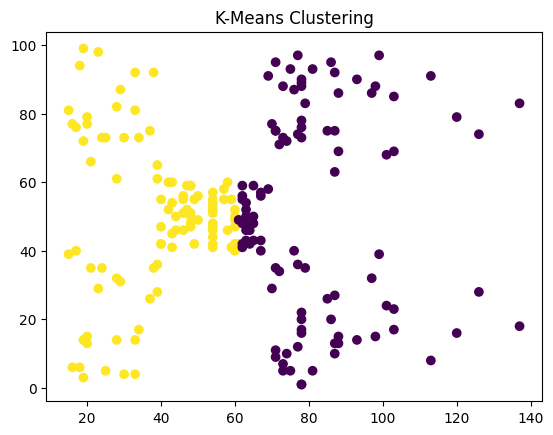

In [47]:
x= data['Annual Income (k$)']
y= data['Spending Score (1-100)']

plt.title("K-Means Clustering")
plt.scatter(x, y, c=kmeans.labels_)
plt.show()